In [7]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns
from scipy.stats import probplot

In [2]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
dataset = MarkerDataset("CD38")
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 64


In [3]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2028
Number of batches in DataLoader: 64


In [4]:
img, label, patient_id = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([2, 140, 140])
Image max value: 0.5738561749458313
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2028


In [ ]:
images, _, _ = dataset

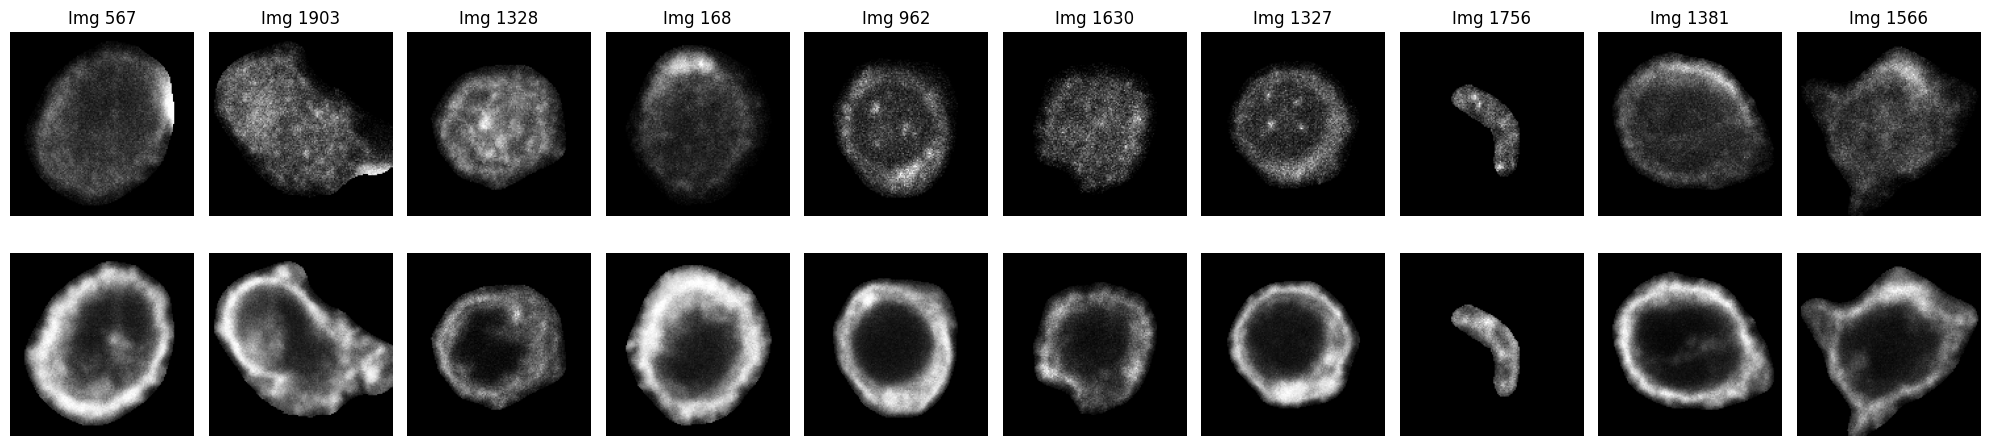

In [6]:
# Randomly select 10 indices
indices = np.random.choice(len(dataset), 10, replace=False)

# Create figure with 2 rows and 10 columns
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, idx in enumerate(indices):
    img, _, _ = dataset[idx]  # Get image and ignore labels
    img = img.numpy()  # Convert tensor to numpy array

    # First row: first channel of the image
    axes[0, i].imshow(img[0], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Img {idx}")

    # Second row: second channel of the image
    axes[1, i].imshow(img[1], cmap='gray')
    axes[1, i].axis('off')

# Set row labels
axes[0, 0].set_ylabel("Channel 1", fontsize=12, rotation=90, labelpad=10)
axes[1, 0].set_ylabel("Channel 2", fontsize=12, rotation=90, labelpad=10)

plt.tight_layout()
plt.show()

In [8]:
def compute_statistics(dataset):
    """
    Compute the mean and standard deviation for each cell image for both channels.
    
    Parameters:
        dataset: A dataset where each item is a tuple (image, label, patient_id)
                 and image is a tensor of shape (2, H, W).
    
    Returns:
        means_channel1, stds_channel1, means_channel2, stds_channel2: numpy arrays 
        with the computed statistics for each channel.
    """
    means_channel1, stds_channel1 = [], []
    means_channel2, stds_channel2 = [], []
    
    for i in range(len(dataset)):
        img, _, _ = dataset[i]
        img_np = img.numpy()  # Convert tensor to numpy array
        # Compute statistics for channel 1 and channel 2
        means_channel1.append(np.mean(img_np[0]))
        stds_channel1.append(np.std(img_np[0]))
        means_channel2.append(np.mean(img_np[1]))
        stds_channel2.append(np.std(img_np[1]))
    
    return (np.array(means_channel1), np.array(stds_channel1), 
            np.array(means_channel2), np.array(stds_channel2))

In [9]:
def plot_histograms(means_channel1, stds_channel1, means_channel2, stds_channel2, bins=30):
    """
    Plot histograms of mean and standard deviation for both channels.
    
    Parameters:
        means_channel1, stds_channel1, means_channel2, stds_channel2: numpy arrays 
            containing statistics for each channel.
        bins: Number of bins for the histograms.
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    axs[0, 0].hist(means_channel1, bins=bins, color='skyblue', edgecolor='black')
    axs[0, 0].set_title("Histogram of Mean Intensity - Channel 1")
    axs[0, 0].set_xlabel("Mean Intensity")
    axs[0, 0].set_ylabel("Frequency")
    
    axs[0, 1].hist(stds_channel1, bins=bins, color='skyblue', edgecolor='black')
    axs[0, 1].set_title("Histogram of Std Intensity - Channel 1")
    axs[0, 1].set_xlabel("Standard Deviation")
    axs[0, 1].set_ylabel("Frequency")
    
    axs[1, 0].hist(means_channel2, bins=bins, color='lightgreen', edgecolor='black')
    axs[1, 0].set_title("Histogram of Mean Intensity - Channel 2")
    axs[1, 0].set_xlabel("Mean Intensity")
    axs[1, 0].set_ylabel("Frequency")
    
    axs[1, 1].hist(stds_channel2, bins=bins, color='lightgreen', edgecolor='black')
    axs[1, 1].set_title("Histogram of Std Intensity - Channel 2")
    axs[1, 1].set_xlabel("Standard Deviation")
    axs[1, 1].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [10]:
def plot_qq(means_channel1, means_channel2):
    """
    Generate Q-Q plots to assess normality of the mean intensities for both channels.
    
    Parameters:
        means_channel1, means_channel2: numpy arrays containing the mean intensities 
            for each channel.
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    probplot(means_channel1, dist="norm", plot=axs[0])
    axs[0].set_title("Q-Q Plot of Means - Channel 1")
    
    probplot(means_channel2, dist="norm", plot=axs[1])
    axs[1].set_title("Q-Q Plot of Means - Channel 2")
    
    plt.tight_layout()
    plt.show()

In [11]:
def plot_scatter(means_channel1, stds_channel1, means_channel2, stds_channel2):
    """
    Plot a scatter plot of Mean vs Standard Deviation per cell for both channels.
    
    Parameters:
        means_channel1, stds_channel1, means_channel2, stds_channel2: numpy arrays 
            containing the statistics for each channel.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(means_channel1, stds_channel1, alpha=0.5, color='blue', label="Channel 1")
    plt.scatter(means_channel2, stds_channel2, alpha=0.5, color='green', label="Channel 2")
    plt.xlabel("Mean Intensity")
    plt.ylabel("Standard Deviation")
    plt.title("Mean vs Standard Deviation per Cell")
    plt.legend()
    plt.show()

In [12]:
means_ch1, stds_ch1, means_ch2, stds_ch2 = compute_statistics(dataset)

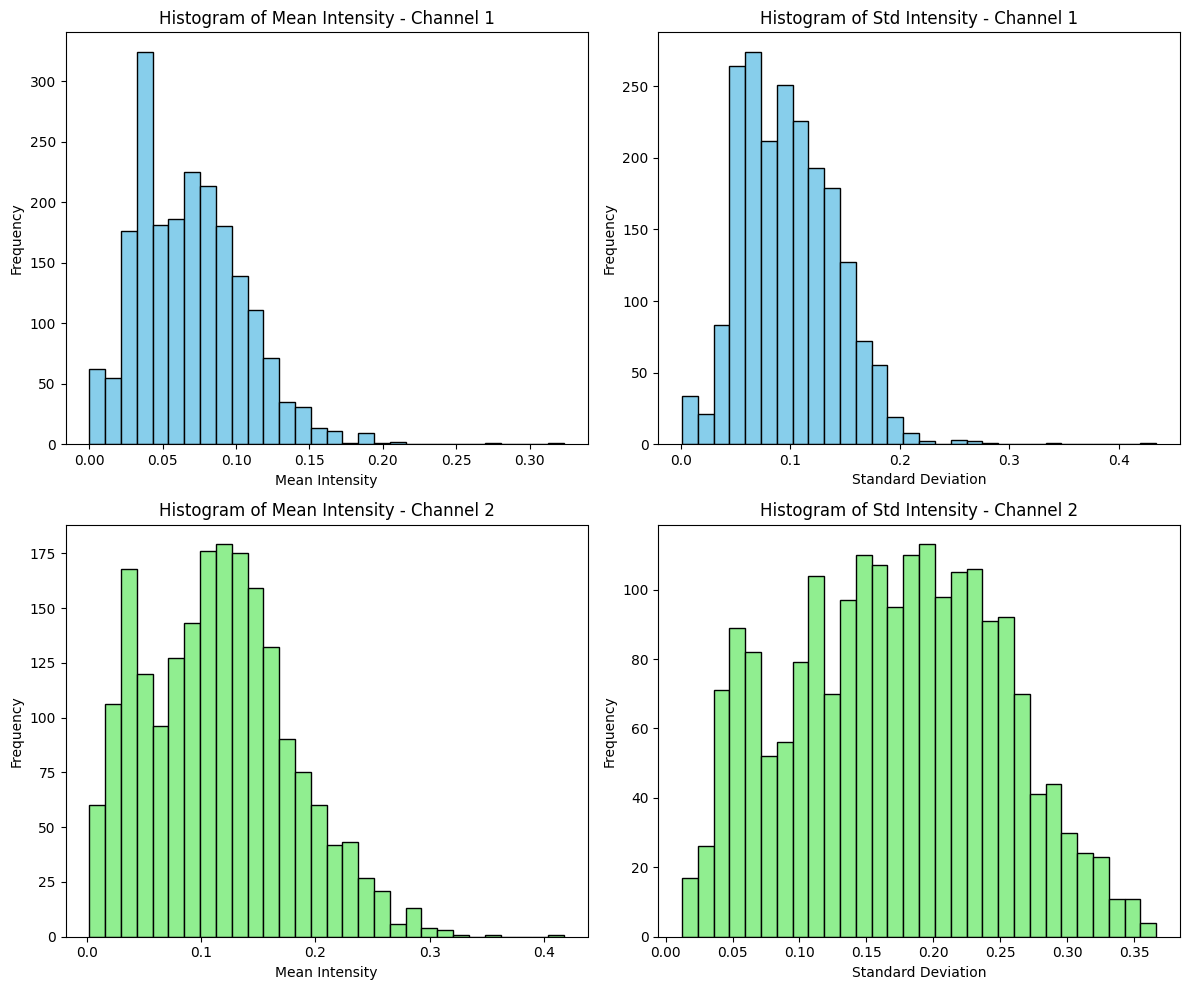

In [13]:
plot_histograms(means_ch1, stds_ch1, means_ch2, stds_ch2)

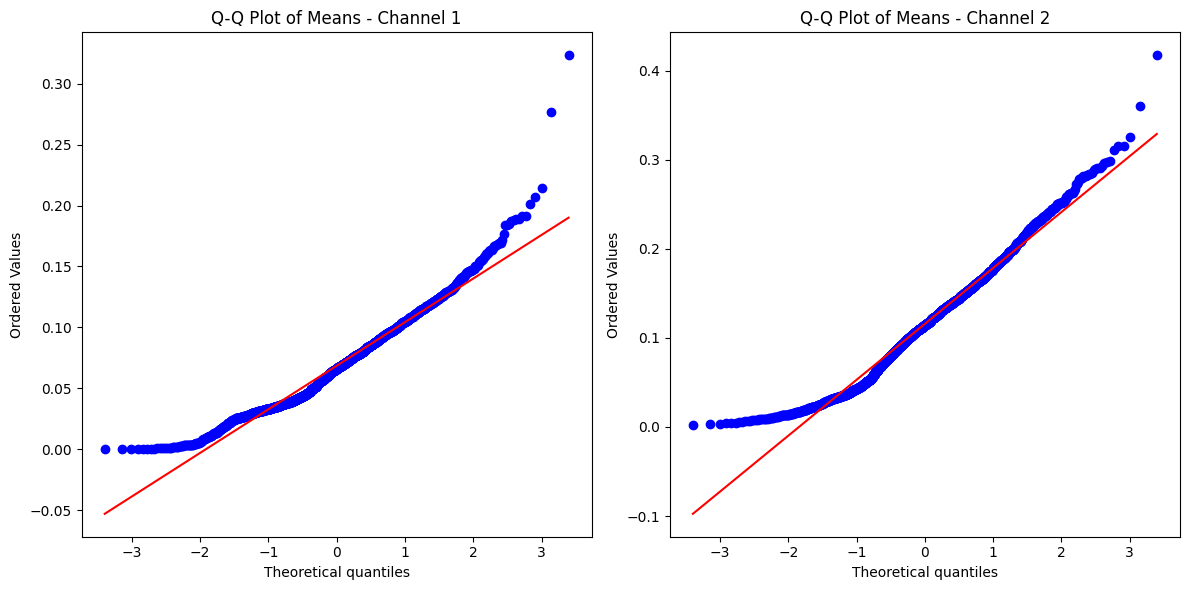

In [14]:
plot_qq(means_ch1, means_ch2)

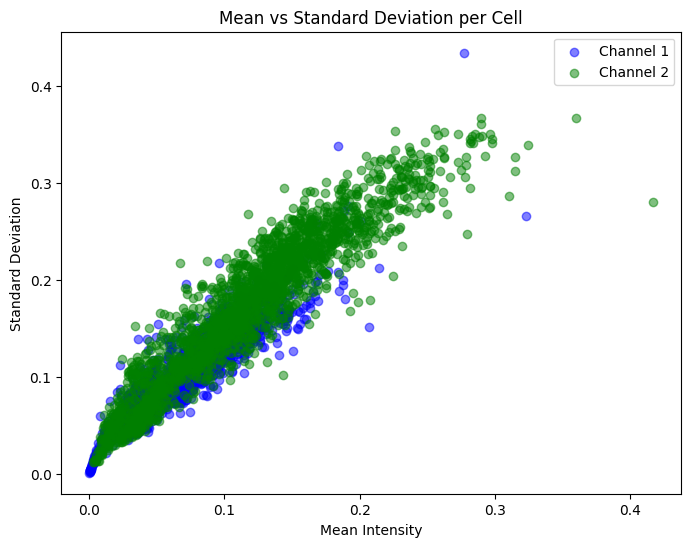

In [15]:
plot_scatter(means_ch1, stds_ch1, means_ch2, stds_ch2)